# <center> Homework 129

In [1]:
import tensorflow_datasets as tfds
from importlib import reload
import tf_data
import tf_model
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_images
import numpy as np
import pandas as pd
from pathlib import Path
import SARIMA_model
from statsmodels.tsa.arima.model import ARIMA
import keras_tuner as kt

2026-02-17 20:44:17.780849: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-17 20:44:18.159545: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-17 20:44:21.928405: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
2026-02-17 20:44:25.768237: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit

In [2]:
def MAPE(y_true, y_pred):
    return tf.reduce_mean(tf.abs((y_true - y_pred) / y_true))

In [2]:
path = Path("datasets/CTA_-_Ridership_-_Daily_Boarding_Totals_20260211.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"] # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1) # no need for total, it's just bus + rail
df = df.drop_duplicates() # remove duplicated months (2011-10 and 2014-07)

df['bus'] = df['bus'].str.replace(",", "").astype(float)
df['rail'] = df['rail'].str.replace(",", "").astype(float)

# Taks 1

на класа SimpleRNN да се добави параметър return_sequences

In [3]:
rail_train = df[['rail']][:'2018-12'].astype(np.float32) / 1e6
rail_test = df[['rail']]['2019-01':'2019-12'].astype(np.float32) / 1e6
seq_length = 100

time_data = []
data_len = len(rail_train)
for i in range(data_len - seq_length):
    start = i
    end   = start + seq_length

    part = rail_train.iloc[start:end].to_numpy()
    time_data.append(part)

X_train = tf.convert_to_tensor(time_data)
y_train = tf.convert_to_tensor(rail_train.iloc[seq_length:].to_numpy())

time_data = []
data_len = len(rail_test)
for i in range(data_len - seq_length):
    start = i
    end   = start + seq_length

    part = rail_test.iloc[start:end].to_numpy()
    time_data.append(part)

X_test = tf.convert_to_tensor(time_data)
y_test = tf.convert_to_tensor(rail_test.iloc[seq_length:].to_numpy())

In [4]:
rail_test_ser = rail_test['rail']

In [12]:
sample = X_train[tf.newaxis, 0]
sample

<tf.Tensor: shape=(1, 100, 1), dtype=float32, numpy=
array([[[0.126455],
        [0.501952],
        [0.536432],
        [0.550011],
        [0.557917],
        [0.255356],
        [0.169825],
        [0.590706],
        [0.599905],
        [0.602052],
        [0.607503],
        [0.605252],
        [0.270056],
        [0.174842],
        [0.412149],
        [0.622163],
        [0.620343],
        [0.618832],
        [0.583851],
        [0.263815],
        [0.172107],
        [0.598777],
        [0.610352],
        [0.606835],
        [0.609877],
        [0.597039],
        [0.268078],
        [0.174434],
        [0.587052],
        [0.607858],
        [0.610508],
        [0.615268],
        [0.577767],
        [0.263612],
        [0.178398],
        [0.600588],
        [0.612435],
        [0.609022],
        [0.610237],
        [0.593354],
        [0.271313],
        [0.17881 ],
        [0.539393],
        [0.622753],
        [0.610966],
        [0.613323],
        [0.601418],
       

In [13]:
reload(tf_model)
from tf_model import SimpleRNN, Input

inp = Input([seq_length, 1])
recurrent = SimpleRNN(16, return_sequences=True)(inp)

recurrent.call(sample)

<tf.Tensor: shape=(1, 100, 16), dtype=float32, numpy=
array([[[ 0.03983223,  0.0161049 ,  0.04667541, ...,  0.01149384,
         -0.04675688,  0.00663636],
        [ 0.26803488,  0.09258497,  0.18174824, ..., -0.01119997,
         -0.1990475 ,  0.05624495],
        [ 0.53732604,  0.18520626,  0.13958356, ..., -0.21282288,
         -0.23635256,  0.1100035 ],
        ...,
        [-0.43230283,  0.9530512 , -0.99952775, ..., -0.96942174,
         -0.9988609 ,  0.9944896 ],
        [-0.6358143 ,  0.94249344, -0.9995103 , ..., -0.97799194,
         -0.9983887 ,  0.99677116],
        [-0.7365388 ,  0.9485685 , -0.9995142 , ..., -0.9591471 ,
         -0.9980049 ,  0.9967586 ]]], shape=(1, 100, 16), dtype=float32)>

## Task 2

да се тества примера от книгата за deep RNN с оригиналния SimpleRNN както и с нашия

In [14]:
deep_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, return_sequences=True, input_shape=[None, 1]),
    tf.keras.layers.SimpleRNN(32, return_sequences=True),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])

deep_model.compile(loss=tf.keras.losses.Huber(),
                   optimizer='adam',
                   metrics=['mae'])

callbacks = [tf.keras.callbacks.EarlyStopping(patience=10, monitor='val_mae', restore_best_weights=True)]
deep_model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), callbacks=callbacks)

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 19s 74ms/step - loss: 0.0066 - mae: 0.0753 - val_loss: 0.0043 - val_mae: 0.0514
Epoch 2/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 30s 121ms/step - loss: 0.0030 - mae: 0.0495 - val_loss: 0.0032 - val_mae: 0.0436
Epoch 3/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 23s 114ms/step - loss: 0.0026 - mae: 0.0459 - val_loss: 0.0033 - val_mae: 0.0537
Epoch 4/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 40s 107ms/step - loss: 0.0027 - mae: 0.0462 - val_loss: 0.0029 - val_mae: 0.0418
Epoch 5/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - loss: 0.0025 - mae: 0.0444 - val_loss: 0.0035 - val_mae: 0.0588
Epoch 6/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - loss: 0.0026 - mae: 0.0470 - val_loss: 0.0029 - val_mae: 0.0437
Epoch 7/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - loss: 0.0026 - mae: 0.0459 - val_loss: 0.0026 - val_mae: 0.0399
Epoch 8/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - loss: 0.0022 - mae: 0.0396 - val_loss: 0.0031 - val_mae: 0.0468
Epoch 9/100
203/203 ━━━━━━━━━

In [16]:
y_pred = deep_model.predict(X_test)
MAPE(y_test, y_pred)

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step


<tf.Tensor: shape=(), dtype=float32, numpy=0.08977049589157104>

In [ ]:
reload(tf_model)
from tf_model import SimpleRNN, Input, Dense, Sequential, EarlyStopping, Adam

deep_model = Sequential([
    Input([seq_length, 1]),
    SimpleRNN(32, return_sequences=True),
    SimpleRNN(32, return_sequences=True),
    SimpleRNN(32),
    Dense(1)
])

callbacks = [EarlyStopping(1, restore_best_weights=True)]
deep_model.compile(loss='mae', optimizer=Adam(0.001), metrics=['mape'])
deep_model.fit(X_train, y_train, epochs=25, validation_data=(X_test, y_test), callbacks=callbacks)

<tf.Variable 'Variable:0' shape=(32, 32) dtype=float32, numpy=
array([[ 0.1111685 ,  0.303771  ,  0.05779925, ..., -0.32128727,
        -0.11396451, -0.01455162],
       [-0.16207886,  0.01326913,  0.35313243, ...,  0.25825417,
         0.11437823, -0.19364795],
       [ 0.30789748,  0.10888759, -0.02995647, ...,  0.00785817,
        -0.26185507, -0.29597008],
       ...,
       [-0.18980697, -0.27606383, -0.00135075, ..., -0.12467247,
        -0.12490972,  0.09202883],
       [-0.02389229,  0.04645198,  0.09231783, ..., -0.01699059,
        -0.09229315,  0.10707875],
       [ 0.05025862,  0.24828114,  0.16985494, ...,  0.22331269,
         0.07720997, -0.0790948 ]], shape=(32, 32), dtype=float32)>
Epoch 1/25


  0%|          | 0/203 [00:00<?, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 

100%|██████████| 203/203 [00:05<00:00, 35.34it/s]


    - loss: 0.075 - meanabsolutepercentageerror: 0.167
    - val_loss: 0.052 - val_meanabsolutepercentageerror: 0.126
    - Learning Rate: 0.001
Epoch 2/25


100%|██████████| 203/203 [00:04<00:00, 50.59it/s]


    - loss: 0.047 - meanabsolutepercentageerror: 0.109
    - val_loss: 0.046 - val_meanabsolutepercentageerror: 0.108
    - Learning Rate: 0.001
Epoch 3/25


100%|██████████| 203/203 [00:04<00:00, 48.56it/s]


    - loss: 0.041 - meanabsolutepercentageerror: 0.097
    - val_loss: 0.046 - val_meanabsolutepercentageerror: 0.107
    - Learning Rate: 0.001


<tf.Variable 'Variable:0' shape=(32, 32) dtype=float32, numpy=
array([[ 0.09241684,  0.29983884,  0.05256964, ..., -0.31457925,
        -0.12638743,  0.00427392],
       [-0.15727213, -0.02198877,  0.33987308, ...,  0.25478476,
         0.13228016, -0.1357346 ],
       [ 0.2886347 ,  0.0983817 , -0.03622589, ...,  0.00662922,
        -0.27335525, -0.30717307],
       ...,
       [-0.19104818, -0.28157347, -0.00229077, ..., -0.12686802,
        -0.11758404,  0.04800084],
       [-0.02152656,  0.0713997 ,  0.09790886, ..., -0.00289619,
        -0.11763619,  0.08988733],
       [-0.00230527,  0.22972973,  0.15828118, ...,  0.20089962,
         0.0536481 , -0.15460803]], shape=(32, 32), dtype=float32)>

In [10]:
y_pred = deep_model.predict(X_test)
MAPE(y_test, y_pred)

<tf.Tensor: shape=(), dtype=float32, numpy=0.1221412792801857>

## Task 3

да се сравни грешката при предсказване на няколко стъпки напред при двата подхода

    последоватлна прогноза определен брой стъпки
    едновременно предсказване

да се визуализират прогнозите спрямо оригиналните данни за следните случаи

    последоватлна прогноза с оригиналния клас (картинката в книгата)
    едновременно предсказване с оригиналния клас
    последоватлна прогноза с нашия клас
    едновременно предсказване с нашия клас


### последоватлна прогноза с оригиналния клас (картинката в книгата)

In [37]:
univar_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 1]),
    tf.keras.layers.Dense(1) 
])

univar_model.compile(loss='mae', optimizer='adam', metrics=['mape'])
callbacks = [tf.keras.callbacks.EarlyStopping(patience=10, monitor='val_loss', restore_best_weights=True)]
univar_model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), callbacks=callbacks)

Epoch 1/100


/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


203/203 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.0940 - mape: 21.7375 - val_loss: 0.0533 - val_mape: 12.7617
Epoch 2/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0480 - mape: 10.9953 - val_loss: 0.0515 - val_mape: 11.8224
Epoch 3/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0424 - mape: 9.8786 - val_loss: 0.0469 - val_mape: 11.0551
Epoch 4/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.0436 - mape: 10.0835 - val_loss: 0.0499 - val_mape: 11.9907
Epoch 5/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.0421 - mape: 9.8174 - val_loss: 0.0470 - val_mape: 10.6269
Epoch 6/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0410 - mape: 9.5631 - val_loss: 0.0430 - val_mape: 10.4253
Epoch 7/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0405 - mape: 9.5008 - val_loss: 0.0424 - val_mape: 10.0921
Epoch 8/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0398 - mape: 9.4291 - val_loss: 0.0421 - val_mape: 10.0550
Epoch 9/100
203/203 ━━━━━

In [39]:
y_pred = univar_model.predict(X_test)
MAPE(y_test, y_pred)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step


<tf.Tensor: shape=(), dtype=float32, numpy=0.0892840251326561>

In [ ]:
X = rail_test_ser.to_numpy()[np.newaxis, :seq_length, np.newaxis]
X.shape

(1, 100, 1)

In [43]:
X = rail_test_ser.to_numpy()[np.newaxis, :seq_length, np.newaxis]
for step_ahead in range(14):
    y_pred_one = univar_model.predict(X)
    X = np.concatenate([X, y_pred_one.reshape(1, 1, 1)], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


<Axes: xlabel='date'>

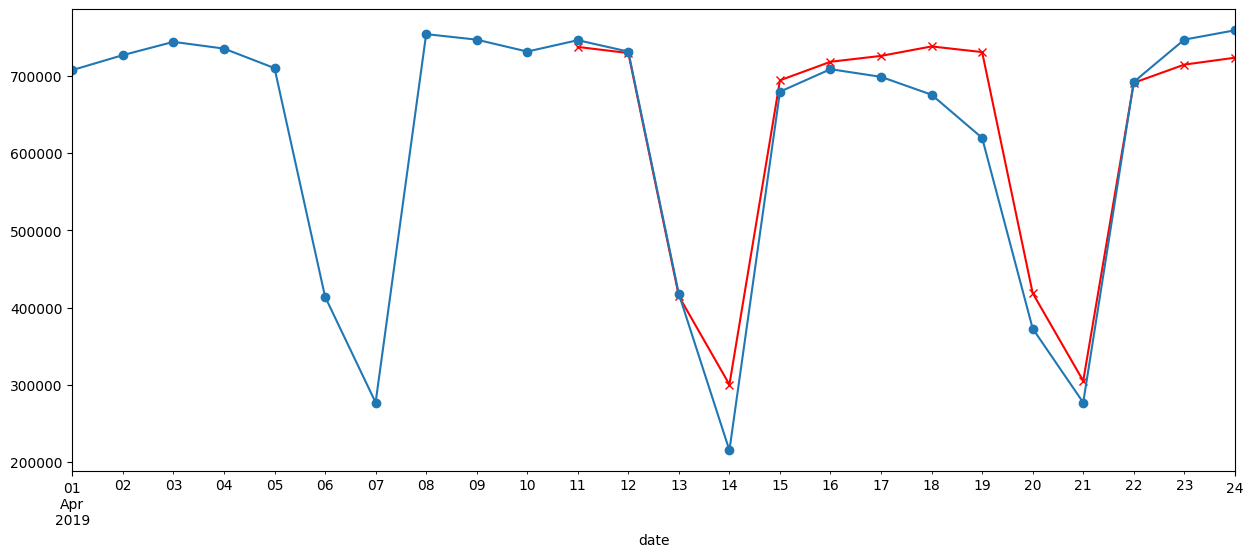

In [54]:
X_ser = pd.Series(np.ravel(X), rail_test_ser.index[:seq_length + 14]) * 1e6

fig, ax = plt.subplots(figsize=(15, 6))
X_ser.iloc[-14:].plot(ax=ax, c='r', marker='x')
(rail_test_ser.iloc[90:114] * 1e6).plot(ax=ax, marker='o')

### едновременно предсказване с оригиналния клас

In [109]:
num_data = df[['bus', 'rail']][:'2019'].astype(np.float32) / 1e6
cat_data = pd.get_dummies(df['day_type'].shift(-1))[:'2019'].astype(np.float32)
mulvar = pd.concat([num_data, cat_data], axis=1)


mulvar_train = mulvar[:'2018']
mulvar_test  = mulvar['2019':]

num_data_train = num_data[:'2018']
num_data_test  = num_data['2019':]

mulvar_test.head()

,bus,rail,A,U,W
date,,,,,
2019-01-01,0.248879,0.245852,0.0,0.0,1.0
2019-01-02,0.591006,0.573542,0.0,0.0,1.0
2019-01-03,0.664442,0.627781,0.0,0.0,1.0
2019-01-04,0.668812,0.628514,1.0,0.0,0.0
2019-01-05,0.444434,0.348257,0.0,1.0,0.0


In [110]:
def split_inputs_and_targets(mulvar_series, ahead=14, target_col=1):
    return mulvar_series[:, :-ahead], mulvar_series[:, -ahead:, target_col]

ahead_train_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(),
    targets=None,
    sequence_length=seq_length + 14,
    batch_size=32,
    shuffle=True,
).map(split_inputs_and_targets)

ahead_valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_test.to_numpy(),
    targets=None,
    sequence_length=seq_length + 14,
    batch_size=32
).map(split_inputs_and_targets)

In [111]:
ahead_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
])

ahead_model.compile(loss='mae', optimizer='adam', metrics=['mape'])
callbacks = [tf.keras.callbacks.EarlyStopping(patience=10, monitor='val_loss', restore_best_weights=True)]
ahead_model.fit(ahead_train_ds, epochs=100, validation_data=(ahead_valid_ds), callbacks=callbacks)

Epoch 1/100


/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


202/202 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 0.1354 - mape: 30.2734 - val_loss: 0.0877 - val_mape: 17.2047
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - loss: 0.0705 - mape: 15.8949 - val_loss: 0.0671 - val_mape: 14.8548
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0522 - mape: 12.2656 - val_loss: 0.0604 - val_mape: 14.2808
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0476 - mape: 11.4350 - val_loss: 0.0527 - val_mape: 11.9492
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0449 - mape: 10.8989 - val_loss: 0.0505 - val_mape: 12.0390
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0440 - mape: 10.7332 - val_loss: 0.0543 - val_mape: 13.0149
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0425 - mape: 10.4421 - val_loss: 0.0476 - val_mape: 11.2971
Epoch 8/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0419 - mape: 10.3053 - val_loss: 0.0477 - val_mape: 11.4814
Epoch 9/100
202/20

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step


<Axes: xlabel='date'>

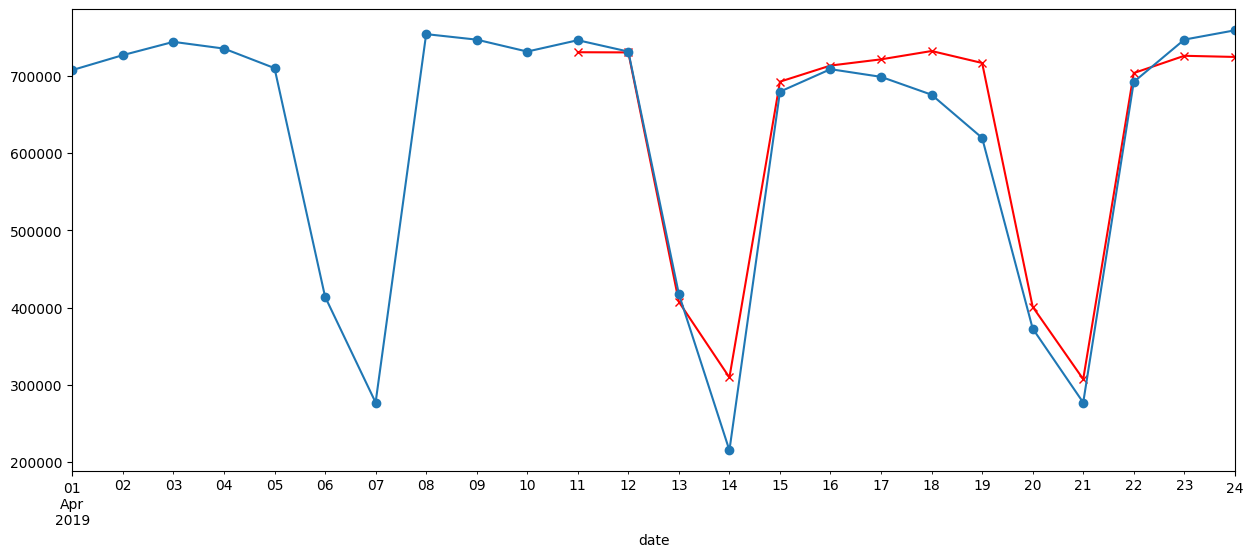

In [116]:
y_true = rail_test_ser[seq_length - 10:seq_length + 14] * 1e6

X = mulvar_test.to_numpy()[np.newaxis, :seq_length]
y_pred = pd.Series(ahead_model.predict(X)[0], y_true.index[-14:]) * 1e6

fig, ax = plt.subplots(figsize=(15, 6))

y_pred.plot(ax=ax, marker='x', c='r')
y_true.plot(ax=ax, marker='o')

### последоватлна прогноза с нашия клас

In [98]:
rail_train = df[['rail']][:'2018-12'].astype(np.float32) / 1e6
rail_test = df[['rail']]['2019-01':'2019-12'].astype(np.float32) / 1e6
seq_length = 30

time_data = []
data_len = len(rail_train)
for i in range(data_len - seq_length):
    start = i
    end   = start + seq_length

    part = rail_train.iloc[start:end].to_numpy()
    time_data.append(part)

X_train = tf.convert_to_tensor(time_data)
y_train = tf.convert_to_tensor(rail_train.iloc[seq_length:].to_numpy())

time_data = []
data_len = len(rail_test)
for i in range(data_len - seq_length):
    start = i
    end   = start + seq_length

    part = rail_test.iloc[start:end].to_numpy()
    time_data.append(part)

X_test = tf.convert_to_tensor(time_data)
y_test = tf.convert_to_tensor(rail_test.iloc[seq_length:].to_numpy())

In [99]:
reload(tf_model)
from tf_model import Sequential, Dense, SimpleRNN, Input, Adam

univar_model = Sequential([
    Input([seq_length, 1]),
    SimpleRNN(32),
    Dense(1) 
])

univar_model.compile(loss='mae', optimizer=Adam(0.01), metrics=['mape'])
univar_model.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test))

Epoch 1/30


  0%|          | 0/205 [00:00<?, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 

100%|██████████| 205/205 [00:02<00:00, 77.50it/s] 


    - loss: 0.137 - meanabsolutepercentageerror: 0.303
    - val_loss: 0.122 - val_meanabsolutepercentageerror: 0.210
    - Learning Rate: 0.01
Epoch 2/30


...

    - loss: 0.119 - meanabsolutepercentageerror: 0.251
    - val_loss: 0.172 - val_meanabsolutepercentageerror: 0.308
    - Learning Rate: 0.01
Epoch 29/30


100%|██████████| 205/205 [00:01<00:00, 148.65it/s]


    - loss: 0.119 - meanabsolutepercentageerror: 0.255
    - val_loss: 0.153 - val_meanabsolutepercentageerror: 0.277
    - Learning Rate: 0.01
Epoch 30/30


100%|██████████| 205/205 [00:01<00:00, 153.75it/s]


    - loss: 0.107 - meanabsolutepercentageerror: 0.231
    - val_loss: 0.122 - val_meanabsolutepercentageerror: 0.217
    - Learning Rate: 0.01


In [100]:
X = rail_test_ser.to_numpy()[np.newaxis, :seq_length, np.newaxis]
for step_ahead in range(14):
    y_pred_one = univar_model.predict(X).numpy()
    X = np.concatenate([X, y_pred_one.reshape(1, 1, 1)], axis=1)

In [37]:
X.shape

(1, 44, 1)

<Axes: xlabel='date'>

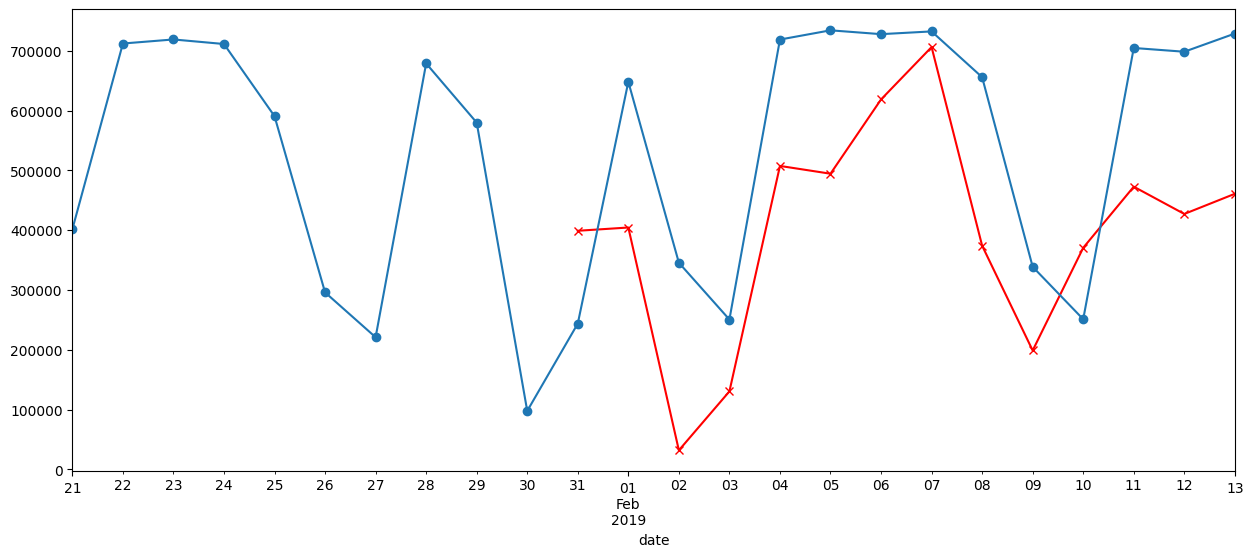

In [101]:
X_ser = pd.Series(np.ravel(X), rail_test_ser.index[:seq_length + 14]) * 1e6

fig, ax = plt.subplots(figsize=(15, 6))
X_ser.iloc[-14:].plot(ax=ax, c='r', marker='x')
(rail_test_ser.iloc[seq_length - 10:seq_length + 14] * 1e6).plot(ax=ax, marker='o')

### едновременно предсказване с нашия клас


In [119]:
reload(tf_data)
from tf_data import timeseries_dataset_from_array

def split_inputs_and_targets(mulvar_series, ahead=14, target_col=1):
    return mulvar_series[:, :-ahead], mulvar_series[:, -ahead:, target_col]

ahead_train_ds = timeseries_dataset_from_array(
    mulvar_train.to_numpy(),
    targets=None,
    sequence_length=seq_length + 14,
    batch_size=32,
    shuffle=True,
).map(split_inputs_and_targets)

ahead_valid_ds = timeseries_dataset_from_array(
    mulvar_test.to_numpy(),
    targets=None,
    sequence_length=seq_length + 14,
    batch_size=32
).map(split_inputs_and_targets)

In [118]:
reload(tf_model)
from tf_model import Sequential, Dense, SimpleRNN, Input

ahead_model = Sequential([
    Input([None, 5]),
    SimpleRNN(32),
    Dense(14)
])

ahead_model.compile(loss='mae', optimizer='adam', metrics=['mape'])
ahead_model.fit(ahead_train_ds, epochs=30, validation_data=(ahead_valid_ds))

ValueError: Attempt to convert a value (<_MapDataset element_spec=(TensorSpec(shape=(None, None, 5), dtype=tf.float32, name=None), TensorSpec(shape=(None, None), dtype=tf.float32, name=None))>) with an unsupported type (<class 'tensorflow.python.data.ops.map_op._MapDataset'>) to a Tensor.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step


<Axes: xlabel='date'>

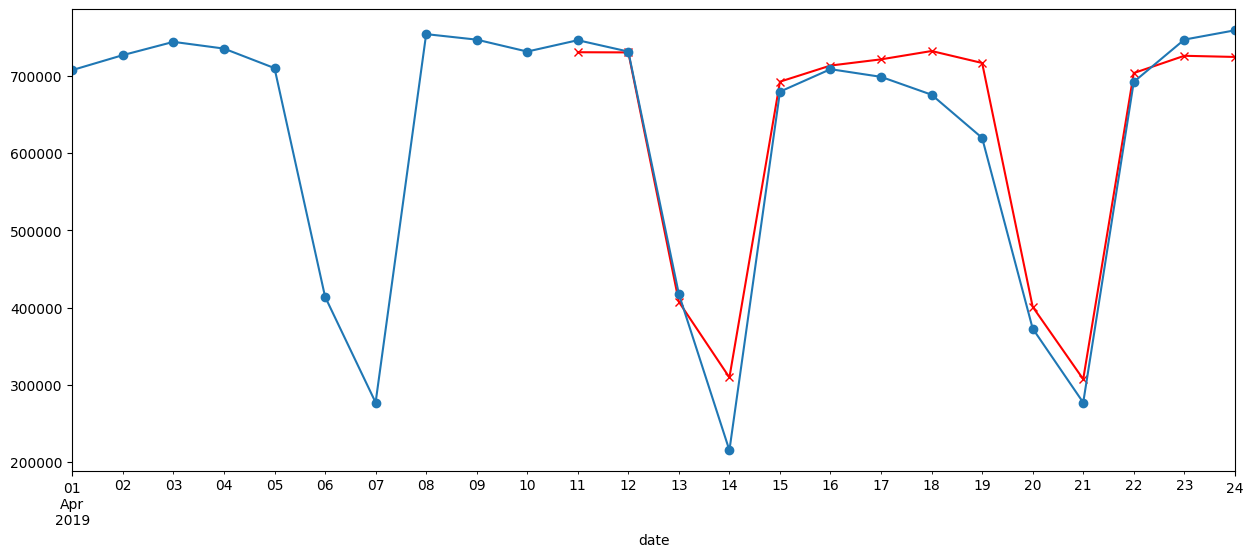

In [117]:
y_true = rail_test_ser[seq_length - 10:seq_length + 14] * 1e6

X = mulvar_test.to_numpy()[np.newaxis, :seq_length]
y_pred = pd.Series(ahead_model.predict(X)[0], y_true.index[-14:]) * 1e6

fig, ax = plt.subplots(figsize=(15, 6))

y_pred.plot(ax=ax, marker='x', c='r')
y_true.plot(ax=ax, marker='o')

## Task 4

да се тества възможно ли е обучение на RNN без да преобразуваме данните генерирани от Dataset в numpy масиви

In [ ]:
frame_len = 30

train_ds = tf.keras.utils.timeseries_dataset_from_array(mulvar_train,
                                                        targets=num_data_train[frame_len:],
                                                        sequence_length=frame_len,
                                                        batch_size=32,
                                                        shuffle=True)

test_ds = tf.keras.utils.timeseries_dataset_from_array(mulvar_test,
                                                        targets=num_data_test[frame_len:],
                                                        sequence_length=frame_len,
                                                        batch_size=32)

In [51]:
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 5]),
    tf.keras.layers.Dense(2)
])

model.compile(loss=tf.keras.losses.Huber(),
              optimizer='adam',
              metrics=['mae'])

model.fit(train_ds, validation_data=(test_ds), epochs=20)

Epoch 1/20


/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0117 - mae: 0.0923 - val_loss: 0.0058 - val_mae: 0.0737
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0040 - mae: 0.0548 - val_loss: 0.0038 - val_mae: 0.0534
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0036 - mae: 0.0517 - val_loss: 0.0038 - val_mae: 0.0566
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0033 - mae: 0.0490 - val_loss: 0.0036 - val_mae: 0.0556
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0032 - mae: 0.0478 - val_loss: 0.0034 - val_mae: 0.0522
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0031 - mae: 0.0472 - val_loss: 0.0032 - val_mae: 0.0534
Epoch 7/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0030 - mae: 0.0466 - val_loss: 0.0028 - val_mae: 0.0500
Epoch 8/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0030 - mae: 0.0457 - val_loss: 0.0030 - val_mae: 0.0499
Epoch 9/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss

## Task 5

да се сравнят резултатите от примера при който обучаваме модел с данни за "bus", "rail" и предсказания за "rail", спрямо модел обучен само с "rail", който предсказва "rail", т.е. да проверим дали подаването на данни за "bus" помага да се подобри прогнозата за "rail".

### - Data => rail
### - Target => rail

In [69]:
rail_df = df[['rail']].astype(np.float32) / 1e6
rail_df_train = rail_df[:'2018'] 
rail_df_test  = rail_df['2019-01':'2019-12'] 

In [70]:
frame_len = 30

train_ds = tf.keras.utils.timeseries_dataset_from_array(rail_df_train,
                                                        targets=rail_df_train[frame_len:],
                                                        sequence_length=frame_len,
                                                        batch_size=32,
                                                        shuffle=True)

test_ds = tf.keras.utils.timeseries_dataset_from_array(rail_df_test,
                                                        targets=rail_df_test[frame_len:],
                                                        sequence_length=frame_len,
                                                        batch_size=32)

In [71]:
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=[None, 1]),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])

model.compile(loss=tf.keras.losses.Huber(),
              optimizer=tf.keras.optimizers.Adam(0.01),
              metrics=['mae'])

callbacks = [tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
model.fit(train_ds, validation_data=(test_ds), epochs=100, callbacks=callbacks)

Epoch 1/100


/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


205/205 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 0.0197 - mae: 0.1538 - val_loss: 0.0065 - val_mae: 0.0906
Epoch 2/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0054 - mae: 0.0790 - val_loss: 0.0038 - val_mae: 0.0529
Epoch 3/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0049 - mae: 0.0740 - val_loss: 0.0032 - val_mae: 0.0573
Epoch 4/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0039 - mae: 0.0635 - val_loss: 0.0028 - val_mae: 0.0470
Epoch 5/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0034 - mae: 0.0579 - val_loss: 0.0028 - val_mae: 0.0444
Epoch 6/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0033 - mae: 0.0565 - val_loss: 0.0042 - val_mae: 0.0655
Epoch 7/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0029 - mae: 0.0510 - val_loss: 0.0032 - val_mae: 0.0548
Epoch 8/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0028 - mae: 0.0497 - val_loss: 0.0025 - val_mae: 0.0439
Epoch 9/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/st

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


('MAPE', np.float32(0.09466471))

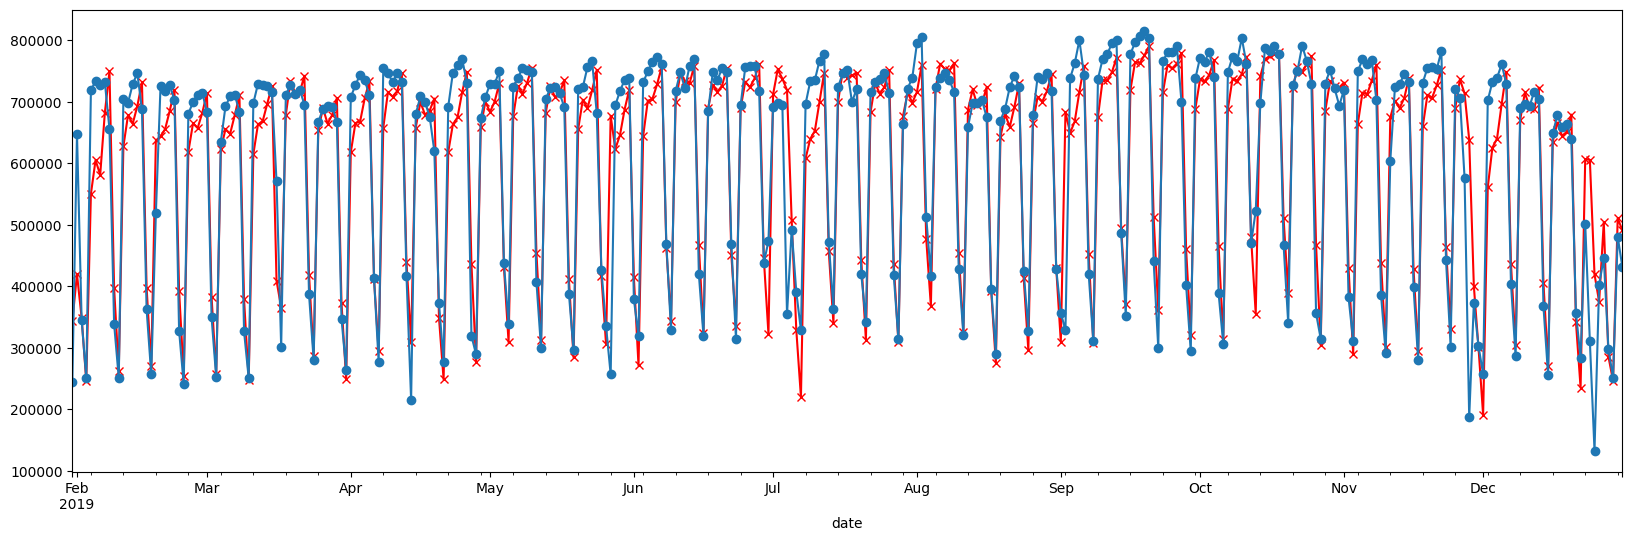

In [75]:
y_true = rail_df_test['rail'][frame_len:] * 1e6
y_pred = pd.Series(np.ravel(model.predict(test_ds)), y_true.index) * 1e6

fig, ax = plt.subplots(figsize=(20, 6))

y_pred.plot(ax=ax, marker='x', c='r')
y_true.plot(ax=ax, marker='o')

mape_rail = ((y_true - y_pred) / y_true).abs().mean()
'MAPE', mape_rail

### - Train => rail, bus
### - Target => rail

In [76]:
bus_rail_df = df[['bus', 'rail']][:'2019'].astype(np.float32) / 1e6
bus_rail_train = bus_rail_df[:'2018']
bus_rail_test  = bus_rail_df['2019-01':'2019-12']

In [77]:
frame_len = 30

train_ds = tf.keras.utils.timeseries_dataset_from_array(bus_rail_train,
                                                        targets=rail_df_train[frame_len:],
                                                        sequence_length=frame_len,
                                                        batch_size=32,
                                                        shuffle=True)

test_ds = tf.keras.utils.timeseries_dataset_from_array(bus_rail_test,
                                                        targets=rail_df_test[frame_len:],
                                                        sequence_length=frame_len,
                                                        batch_size=32)

In [78]:
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=[None, 2]),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])

model.compile(loss=tf.keras.losses.Huber(),
              optimizer=tf.keras.optimizers.Adam(0.01),
              metrics=['mae'])

callbacks = [tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
model.fit(train_ds, validation_data=(test_ds), epochs=100, callbacks=callbacks)

Epoch 1/100


/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


205/205 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.0341 - mae: 0.1527 - val_loss: 0.0072 - val_mae: 0.0803
Epoch 2/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0060 - mae: 0.0831 - val_loss: 0.0032 - val_mae: 0.0506
Epoch 3/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0054 - mae: 0.0778 - val_loss: 0.0034 - val_mae: 0.0560
Epoch 4/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0047 - mae: 0.0706 - val_loss: 0.0032 - val_mae: 0.0491
Epoch 5/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0038 - mae: 0.0623 - val_loss: 0.0052 - val_mae: 0.0803
Epoch 6/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0035 - mae: 0.0584 - val_loss: 0.0036 - val_mae: 0.0545
Epoch 7/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0034 - mae: 0.0568 - val_loss: 0.0025 - val_mae: 0.0400
Epoch 8/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0048 - mae: 0.0685 - val_loss: 0.0036 - val_mae: 0.0583
Epoch 9/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/ste

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


('MAPE', np.float32(0.09949327))

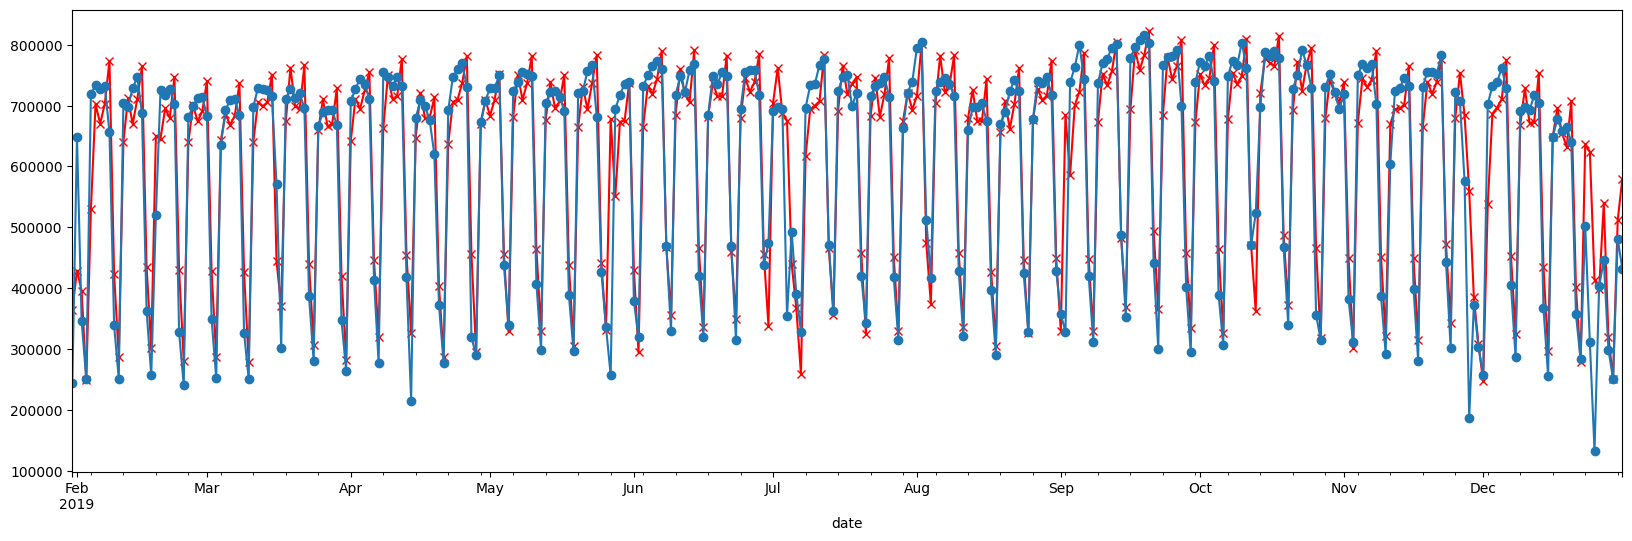

In [80]:
y_true = rail_df_test['rail'][frame_len:] * 1e6
y_pred = pd.Series(np.ravel(model.predict(test_ds)), y_true.index) * 1e6

fig, ax = plt.subplots(figsize=(20, 6))

y_pred.plot(ax=ax, marker='x', c='r')
y_true.plot(ax=ax, marker='o')

mape_rail_bus = ((y_true - y_pred) / y_true).abs().mean()
'MAPE', mape_rail_bus

### - Train => rail, day_type
### - Target => rail

In [86]:
day_type = pd.get_dummies(df['day_type'])[:'2019'].astype(np.float32)
day_type_train = day_type[:'2018']
day_type_test  = day_type['2019-01':'2019-12']

rail_daytype_train = pd.concat([rail_df_train, day_type_train], axis=1)
rail_daytype_test  = pd.concat([rail_df_test, day_type_test], axis=1)

In [87]:
rail_daytype_test

,rail,A,U,W
date,,,,
2019-01-01,0.245852,0.0,1.0,0.0
2019-01-02,0.573542,0.0,0.0,1.0
2019-01-03,0.627781,0.0,0.0,1.0
2019-01-04,0.628514,0.0,0.0,1.0
2019-01-05,0.348257,1.0,0.0,0.0
...,...,...,...,...
2019-12-27,0.445835,0.0,0.0,1.0
2019-12-28,0.298646,1.0,0.0,0.0
2019-12-29,0.251105,0.0,1.0,0.0


In [89]:
frame_len = 30

train_ds = tf.keras.utils.timeseries_dataset_from_array(rail_daytype_train,
                                                        targets=rail_df_train[frame_len:],
                                                        sequence_length=frame_len,
                                                        batch_size=32,
                                                        shuffle=True)

test_ds = tf.keras.utils.timeseries_dataset_from_array(rail_daytype_test,
                                                        targets=rail_df_test[frame_len:],
                                                        sequence_length=frame_len,
                                                        batch_size=32)

In [90]:
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=[None, 4]),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])

model.compile(loss=tf.keras.losses.Huber(),
              optimizer=tf.keras.optimizers.Adam(0.01),
              metrics=['mae'])

callbacks = [tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
model.fit(train_ds, validation_data=(test_ds), epochs=100, callbacks=callbacks)

Epoch 1/100


/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


205/205 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0263 - mae: 0.1371 - val_loss: 0.0182 - val_mae: 0.1693
Epoch 2/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0221 - mae: 0.1470 - val_loss: 0.0065 - val_mae: 0.0927
Epoch 3/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0061 - mae: 0.0830 - val_loss: 0.0048 - val_mae: 0.0560
Epoch 4/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0075 - mae: 0.0914 - val_loss: 0.0068 - val_mae: 0.0868
Epoch 5/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.0183 - mae: 0.1405 - val_loss: 0.0162 - val_mae: 0.1536
Epoch 6/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0112 - mae: 0.1178 - val_loss: 0.0167 - val_mae: 0.1738
Epoch 7/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0099 - mae: 0.1086 - val_loss: 0.0094 - val_mae: 0.1145
Epoch 8/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0104 - mae: 0.1116 - val_loss: 0.0056 - val_mae: 0.0689
Epoch 9/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/ste

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step


('MAPE', np.float32(0.09948767))

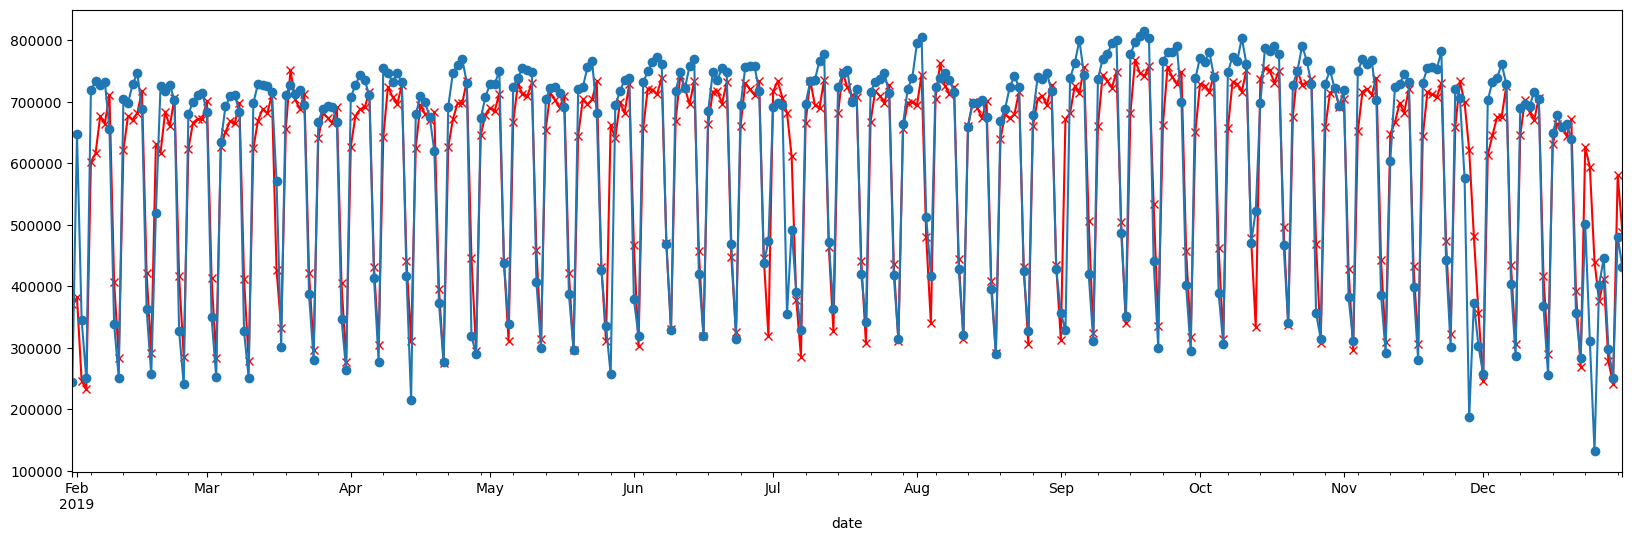

In [91]:
y_true = rail_df_test['rail'][frame_len:] * 1e6
y_pred = pd.Series(np.ravel(model.predict(test_ds)), y_true.index) * 1e6

fig, ax = plt.subplots(figsize=(20, 6))

y_pred.plot(ax=ax, marker='x', c='r')
y_true.plot(ax=ax, marker='o')

mape_rail_daytype = ((y_true - y_pred) / y_true).abs().mean()
'MAPE', mape_rail_daytype

### - Train => rail, bus, day_type
### - Target => rail

In [92]:
full_df_train = pd.concat([bus_rail_train, day_type_train], axis=1)
full_df_test  = pd.concat([bus_rail_test, day_type_test], axis=1)

In [93]:
full_df_test

,bus,rail,A,U,W
date,,,,,
2019-01-01,0.248879,0.245852,0.0,1.0,0.0
2019-01-02,0.591006,0.573542,0.0,0.0,1.0
2019-01-03,0.664442,0.627781,0.0,0.0,1.0
2019-01-04,0.668812,0.628514,0.0,0.0,1.0
2019-01-05,0.444434,0.348257,1.0,0.0,0.0
...,...,...,...,...,...
2019-12-27,0.552198,0.445835,0.0,0.0,1.0
2019-12-28,0.394869,0.298646,1.0,0.0,0.0
2019-12-29,0.315428,0.251105,0.0,1.0,0.0


In [94]:
frame_len = 30

train_ds = tf.keras.utils.timeseries_dataset_from_array(full_df_train,
                                                        targets=rail_df_train[frame_len:],
                                                        sequence_length=frame_len,
                                                        batch_size=32,
                                                        shuffle=True)

test_ds = tf.keras.utils.timeseries_dataset_from_array(full_df_test,
                                                        targets=rail_df_test[frame_len:],
                                                        sequence_length=frame_len,
                                                        batch_size=32)

In [95]:
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])

model.compile(loss=tf.keras.losses.Huber(),
              optimizer=tf.keras.optimizers.Adam(0.01),
              metrics=['mae'])

callbacks = [tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
model.fit(train_ds, validation_data=(test_ds), epochs=100, callbacks=callbacks)

Epoch 1/100


/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


205/205 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0139 - mae: 0.0990 - val_loss: 0.0119 - val_mae: 0.1427
Epoch 2/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0049 - mae: 0.0736 - val_loss: 0.0042 - val_mae: 0.0703
Epoch 3/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0042 - mae: 0.0666 - val_loss: 0.0027 - val_mae: 0.0419
Epoch 4/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0032 - mae: 0.0552 - val_loss: 0.0029 - val_mae: 0.0467
Epoch 5/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 0.0029 - mae: 0.0516 - val_loss: 0.0025 - val_mae: 0.0433
Epoch 6/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - loss: 0.0030 - mae: 0.0541 - val_loss: 0.0029 - val_mae: 0.0544
Epoch 7/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 0.0027 - mae: 0.0499 - val_loss: 0.0026 - val_mae: 0.0390
Epoch 8/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0029 - mae: 0.0519 - val_loss: 0.0035 - val_mae: 0.0648
Epoch 9/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


('MAPE', np.float32(0.08756707))

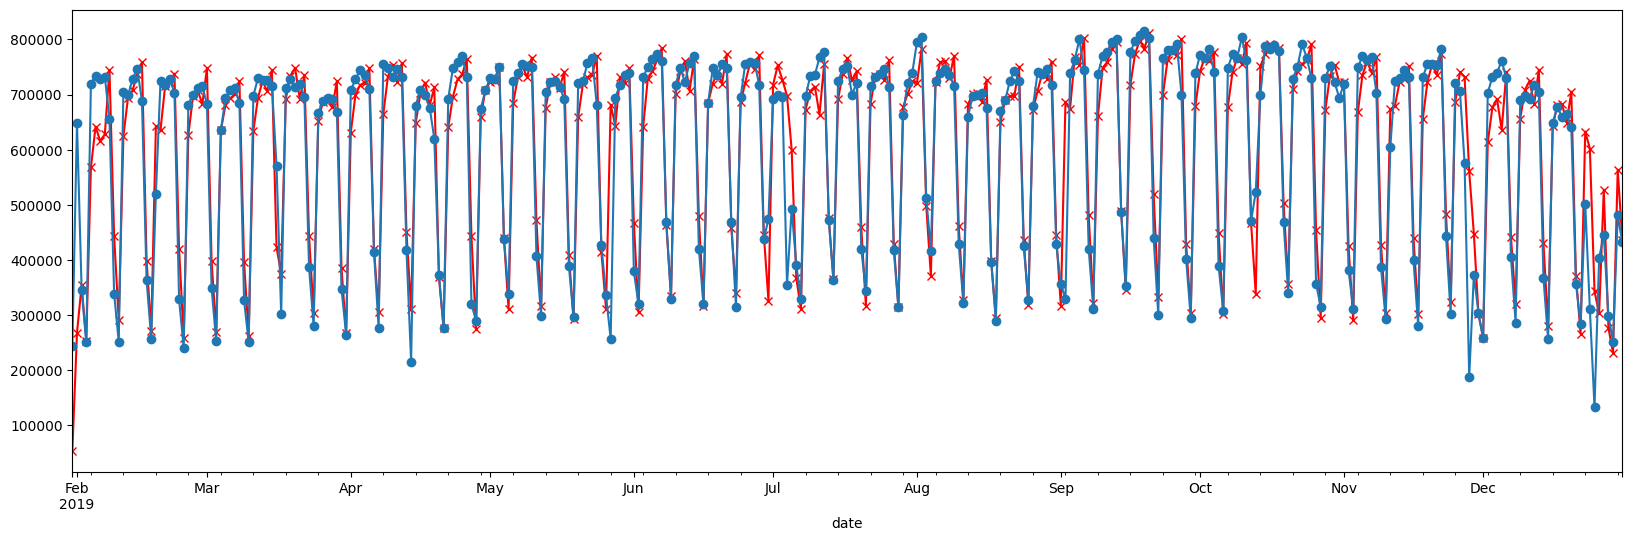

In [96]:
y_true = rail_df_test['rail'][frame_len:] * 1e6
y_pred = pd.Series(np.ravel(model.predict(test_ds)), y_true.index) * 1e6

fig, ax = plt.subplots(figsize=(20, 6))

y_pred.plot(ax=ax, marker='x', c='r')
y_true.plot(ax=ax, marker='o')

mape_full = ((y_true - y_pred) / y_true).abs().mean()
'MAPE', mape_full

In [97]:
pd.Series(
    [mape_rail, mape_rail_bus, mape_rail_daytype, mape_full],
    ['Rail', 'Bus, Rail', 'Rail, DayType', 'Bus, Rail, DayType'],
    name='MAPE Reuslts'
)

Rail                  0.094665
Bus, Rail             0.099493
Rail, DayType         0.099488
Bus, Rail, DayType    0.087567
Name: MAPE Reuslts, dtype: float32